# Bibliotecas

In [1]:
! pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 2.8 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
from brevitas.export import export_qonnx
import onnx
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import gc
from brevitas.nn import QuantConv2d, QuantLinear, QuantReLU, TruncAvgPool2d
from brevitas.quant import Int32Bias
from configparser import ConfigParser
from torch.nn import Sequential
from brevitas.core.restrict_val import RestrictValueType
from brevitas.quant import Int8ActPerTensorFloat
from brevitas.quant import Int8WeightPerTensorFloat
from brevitas.quant import Uint8ActPerTensorFloat
from tqdm import tqdm
import copy
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from brevitas.export import export_qonnx
from qonnx.core.modelwrapper import ModelWrapper
from qonnx.util.cleanup import cleanup as qonnx_cleanup
from qonnx.core.datatype import DataType
from finn.transformation.qonnx.convert_qonnx_to_finn import ConvertQONNXtoFINN
from finn.util.visualization import showSrc
from qonnx.transformation.general import GiveReadableTensorNames, GiveUniqueNodeNames,RemoveStaticGraphInputs
from qonnx.transformation.infer_shapes import InferShapes
from qonnx.transformation.infer_datatypes import InferDataTypes
from qonnx.transformation.fold_constants import FoldConstants
import finn.transformation.streamline.absorb as absorb
import finn.transformation.streamline.reorder as reorder
from finn.transformation.streamline import Streamline
from qonnx.transformation.double_to_single_float import DoubleToSingleFloat
from qonnx.transformation.change_datalayout import ChangeDataLayoutQuantAvgPool2d
from qonnx.transformation.infer_data_layouts import InferDataLayouts
from finn.transformation.streamline.collapse_repeated import CollapseRepeatedMul
from qonnx.transformation.remove import RemoveIdentityOps
from finn.transformation.streamline.round_thresholds import RoundAndClipThresholds
from qonnx.transformation.lower_convs_to_matmul import LowerConvsToMatMul
import finn.transformation.fpgadataflow.convert_to_hw_layers as to_hw
from finn.transformation.fpgadataflow.create_dataflow_partition import CreateDataflowPartition
import finn.builder.build_dataflow as build
import finn.builder.build_dataflow_config as build_cfg
import shutil
from finn.transformation.streamline.reorder import MoveScalarLinearPastInvariants, MakeMaxPoolNHWC
from qonnx.transformation.insert_topk import InsertTopK
from finn.transformation.streamline.absorb import AbsorbScalarMulAddIntoTopK,AbsorbAddIntoMultiThreshold,AbsorbMulIntoMultiThreshold
from torchvision.models import vgg11, VGG11_Weights
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, confusion_matrix
from tqdm import tqdm
from brevitas import config
import warnings

# Dataset

In [3]:
BASE_PATH = 'DDR-dataset/DR_grading'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VALID_PATH = os.path.join(BASE_PATH, 'valid')
TEST_PATH = os.path.join(BASE_PATH, 'test')

In [4]:
def load_labels(file_path):
    labels = pd.read_csv(file_path, sep=' ', header=None, names=['filename', 'label'])
    return labels

train_labels = load_labels(os.path.join(BASE_PATH, 'train.txt'))
valid_labels = load_labels(os.path.join(BASE_PATH, 'valid.txt'))
test_labels = load_labels(os.path.join(BASE_PATH, 'test.txt'))

In [5]:
class CustomDataset(Dataset):
    def __init__(self, labels, dir_path, transform=None):
        self.labels = labels
        self.dir_path = dir_path
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_name = os.path.join(self.dir_path, self.labels.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')
        label = int(self.labels.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
BATCH_SIZE = 16  # Tamanho do batch

train_dataset = CustomDataset(train_labels, TRAIN_PATH, transform=train_transform)
valid_dataset = CustomDataset(valid_labels, VALID_PATH, transform=test_transform)
test_dataset = CustomDataset(test_labels, TEST_PATH, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Dicionário com os nomes das classes
CLASS_NAMES = {
    0: 'Sem RD',
    1: 'RDNP leve',
    2: 'RDNP moderada',
    3: 'RDNP grave',
    4: 'RDP',
    5: 'Não classificável'
}

def denormalize(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Desfaz a normalização para exibir a imagem corretamente."""
    mean = np.array(mean)
    std = np.array(std)
    img = img_tensor.numpy().transpose((1, 2, 0))  # C,H,W -> H,W,C
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def get_one_sample_per_class(labels_df, seed=42):
    """Retorna um dataframe com uma amostra (linha) por classe, ordenado pela classe."""
    classes = sorted(labels_df['label'].unique())
    samples = []
    for cls in classes:
        sample = labels_df[labels_df['label'] == cls].sample(n=1, random_state=seed)
        samples.append(sample)
    return pd.concat(samples).reset_index(drop=True)

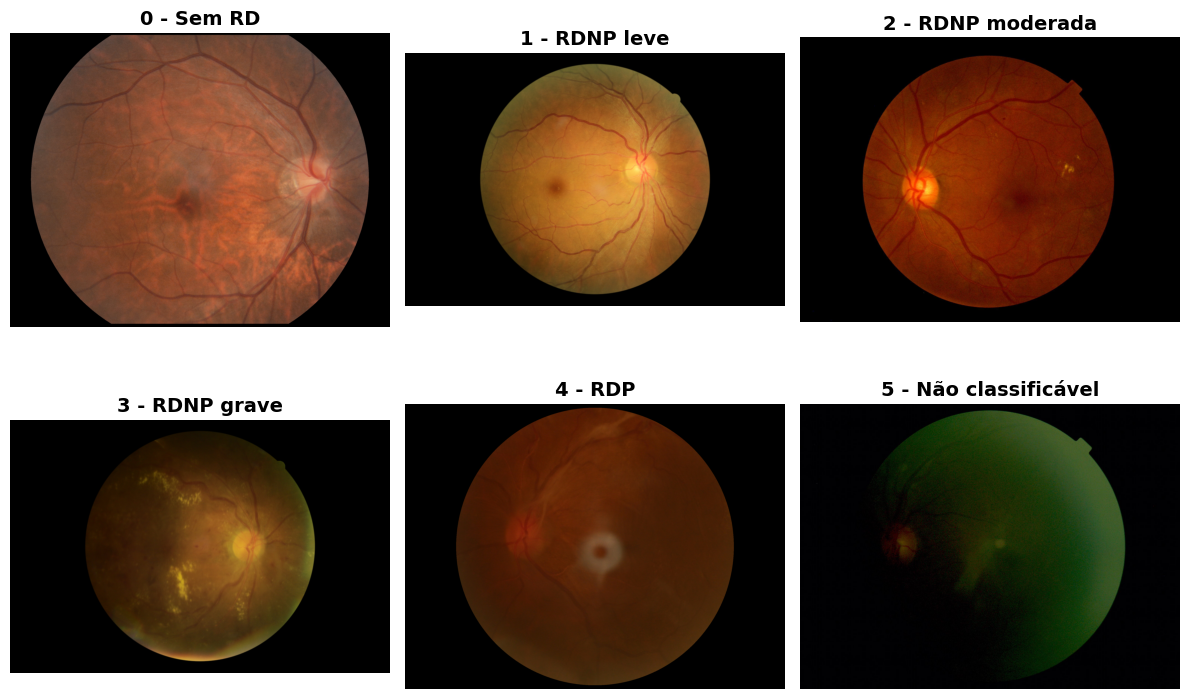

In [24]:
def show_classes_dataset(labels_df, dir_path, save_path, seed=42):
    """Exibe uma imagem original (sem transformação) por classe, em grade 2x3."""
    samples = get_one_sample_per_class(labels_df, seed=seed)
    n_classes = len(samples)

    n_cols = 3
    n_rows = int(np.ceil(n_classes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = axes.flatten()  # facilita a indexação linear

    for i, row in samples.iterrows():
        img_name = os.path.join(dir_path, row['filename'])
        image = Image.open(img_name).convert('RGB')

        axes[i].imshow(image)
        axes[i].set_title(f"{row['label']} - {CLASS_NAMES[row['label']]}", fontsize=14, fontweight='bold')
        axes[i].axis('off')

    # Desliga eixos extras, caso n_classes não seja múltiplo de n_cols
    for j in range(n_classes, len(axes)):
        axes[j].axis('off')

    #plt.suptitle('Classes presentes no dataset', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Executar
show_classes_dataset(train_labels, TRAIN_PATH, save_path='classes_dataset.png')

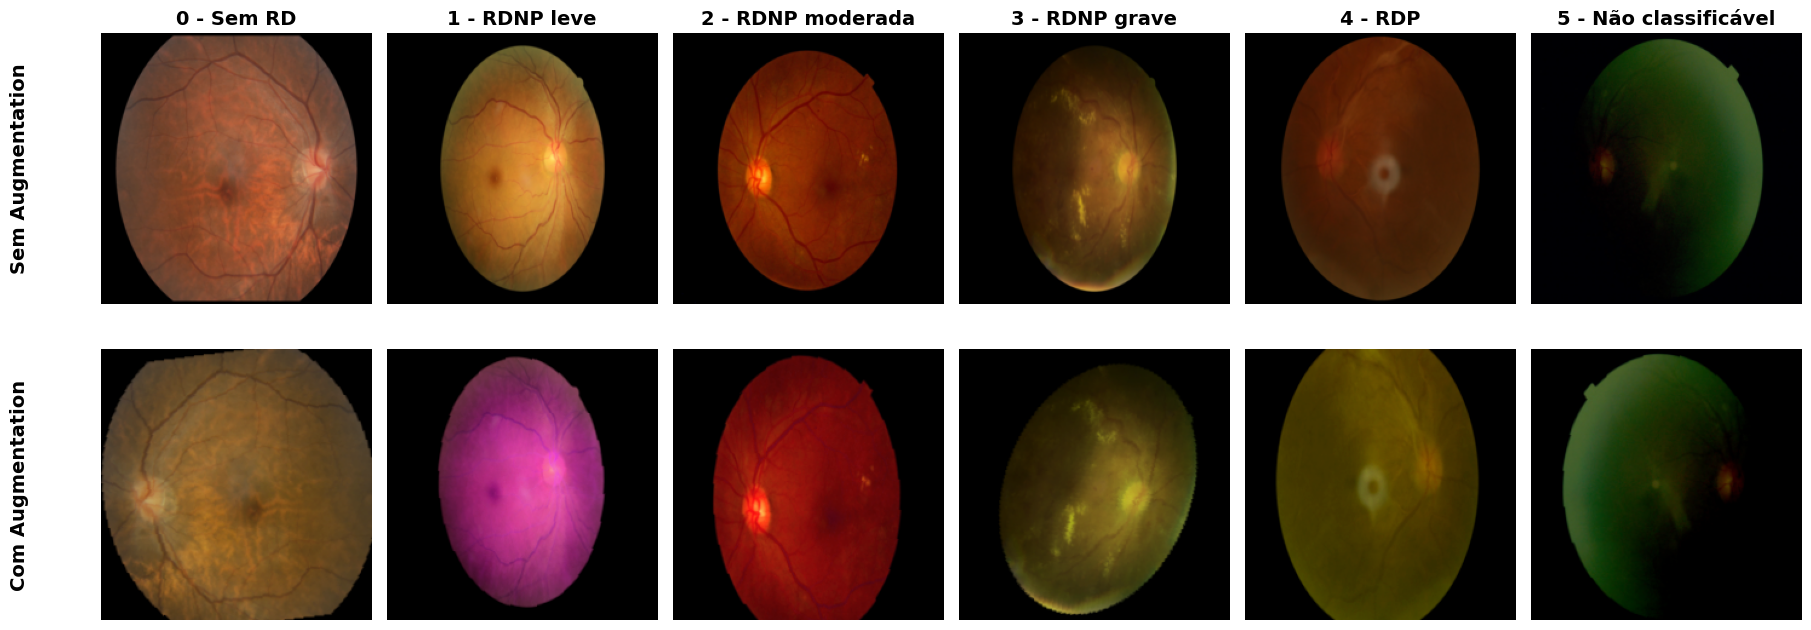

In [23]:
def show_augmentation_comparison(labels_df, dir_path, transform_no_aug, transform_aug, seed=42, save_path='augmentation_comparison.png'):
    """
    Exibe duas linhas de imagens (uma por classe em cada linha):
    - Linha 1: sem data augmentation
    - Linha 2: com data augmentation
    """
    samples = get_one_sample_per_class(labels_df, seed=seed)
    n_classes = len(samples)

    fig, axes = plt.subplots(2, n_classes, figsize=(n_classes * 3, 7))
    plt.subplots_adjust(hspace=0.05)  # reduz espaço vertical entre as linhas

    for i, row in samples.iterrows():
        img_name = os.path.join(dir_path, row['filename'])
        image = Image.open(img_name).convert('RGB')

        # Sem augmentation
        img_no_aug = transform_no_aug(image)
        img_no_aug_display = denormalize(img_no_aug)
        axes[0, i].imshow(img_no_aug_display)
        axes[0, i].set_title(f"{row['label']} - {CLASS_NAMES[row['label']]}", fontsize=14, fontweight='bold')
        axes[0, i].axis('off')

        # Com augmentation
        img_aug = transform_aug(image)
        img_aug_display = denormalize(img_aug)
        axes[1, i].imshow(img_aug_display)
        axes[1, i].axis('off')

    # Labels nas linhas
    axes[0, 0].text(-0.3, 0.5, 'Sem Augmentation', fontsize=14, fontweight='bold',
                     rotation=90, va='center', ha='center', transform=axes[0, 0].transAxes)
    axes[1, 0].text(-0.3, 0.5, 'Com Augmentation', fontsize=14, fontweight='bold',
                     rotation=90, va='center', ha='center', transform=axes[1, 0].transAxes)

    #plt.suptitle('Comparação: Sem vs Com Data Augmentation', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Executar
show_augmentation_comparison(train_labels, TRAIN_PATH, test_transform, train_transform)

# Definindo modelo não quantizado

In [8]:
weights = VGG11_Weights.DEFAULT
model = vgg11(weights=weights)

num_ftrs = model.classifier[0].in_features  # 512*7*7
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 6)
)

Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /tmp/home_dir/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


  0%|          | 0.00/507M [00:00<?, ?B/s]

In [9]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

# Definindo o modelo quantizado

In [10]:
# Copyright (C) 2023, Advanced Micro Devices, Inc. All rights reserved.
# SPDX-License-Identifier: BSD-3-Clause

class CommonIntWeightPerTensorQuant(Int8WeightPerTensorFloat):
    scaling_min_val = 2e-16
    bit_width = None

class CommonIntWeightPerChannelQuant(CommonIntWeightPerTensorQuant):
    scaling_per_output_channel = True

class CommonIntActQuant(Int8ActPerTensorFloat):
    scaling_min_val = 2e-16
    bit_width = None
    restrict_scaling_type = RestrictValueType.LOG_FP

class CommonUintActQuant(Uint8ActPerTensorFloat):
    scaling_min_val = 2e-16
    bit_width = None
    restrict_scaling_type = RestrictValueType.LOG_FP

In [11]:
# BSD 3-Clause License
# Copyright (c) Alessandro Pappalardo 2019,
# Copyright (c) Soumith Chintala 2016,
# All rights reserved.

class QuantVGG11(nn.Module):
    def __init__(self, weight_bit_width, act_bit_width, num_classes=6):
        super(QuantVGG11, self).__init__()
        
        self.features = nn.Sequential(
            # Bloco 1
            QuantConv2d(3, 64, kernel_size=3, stride=1, padding=1,groups=1,
                        bias=True, weight_bit_width=weight_bit_width,
                        weight_quant=CommonIntWeightPerChannelQuant),
            QuantReLU(act_quant=CommonUintActQuant,
                      bit_width=act_bit_width, return_quant_tensor=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Bloco 2
            QuantConv2d(64, 128, kernel_size=3, stride=1, padding=1,groups=1,
                        bias=True, weight_bit_width=weight_bit_width,
                        weight_quant=CommonIntWeightPerChannelQuant),
            QuantReLU(act_quant=CommonUintActQuant,
                      bit_width=act_bit_width, return_quant_tensor=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Bloco 3
            QuantConv2d(128, 256, kernel_size=3, stride=1, padding=1,groups=1,
                        bias=True, weight_bit_width=weight_bit_width,
                        weight_quant=CommonIntWeightPerChannelQuant),
            QuantReLU(act_quant=CommonUintActQuant,
                      bit_width=act_bit_width, return_quant_tensor=True),
            
            QuantConv2d(256, 256, kernel_size=3, stride=1, padding=1,groups=1,
                        bias=True, weight_bit_width=weight_bit_width,
                        weight_quant=CommonIntWeightPerChannelQuant),
            QuantReLU(act_quant=CommonUintActQuant,
                      bit_width=act_bit_width, return_quant_tensor=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Bloco 4
            QuantConv2d(256, 512, kernel_size=3, stride=1, padding=1,groups=1,
                        bias=True, weight_bit_width=weight_bit_width,
                        weight_quant=CommonIntWeightPerChannelQuant),
            QuantReLU(act_quant=CommonUintActQuant,
                      bit_width=act_bit_width, return_quant_tensor=True),
            
            QuantConv2d(512, 512, kernel_size=3, stride=1, padding=1,groups=1,
                        bias=True, weight_bit_width=weight_bit_width,
                        weight_quant=CommonIntWeightPerChannelQuant),
            QuantReLU(act_quant=CommonUintActQuant,
                      bit_width=act_bit_width, return_quant_tensor=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Bloco 5
            QuantConv2d(512, 512, kernel_size=3, stride=1, padding=1,groups=1,
                        bias=True, weight_bit_width=weight_bit_width,
                        weight_quant=CommonIntWeightPerChannelQuant),
            QuantReLU(act_quant=CommonUintActQuant,
                      bit_width=act_bit_width, return_quant_tensor=True),
            
            QuantConv2d(512, 512, kernel_size=3, stride=1, padding=1,groups=1,
                        bias=True, weight_bit_width=weight_bit_width,
                        weight_quant=CommonIntWeightPerChannelQuant),
            QuantReLU(act_quant=CommonUintActQuant,
                      bit_width=act_bit_width, return_quant_tensor=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
        )


        self.classifier = nn.Sequential(
            QuantLinear(512*7*7, 
                        256, 
                        bias=True, 
                        weight_quant=CommonIntWeightPerChannelQuant,
                        weight_bit_width=weight_bit_width),
            QuantReLU(act_quant=CommonUintActQuant, 
                      bit_width=act_bit_width, 
                      return_quant_tensor=True),
            nn.Dropout(0.4),
            QuantLinear(256, 
                        num_classes, 
                        bias=True, 
                        weight_quant=CommonIntWeightPerChannelQuant,
                        weight_bit_width=weight_bit_width),
        )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

# Treinando o modelo não quantizado

In [19]:
def train_model(model, criterion, optimizer, train_loader, valid_loader, model_name, num_epochs=20):
    best_model_wts = model.state_dict()
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                data_loader = train_loader
            else:
                model.eval()
                data_loader = valid_loader
                
            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []
            
            for inputs, labels in data_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            
            epoch_loss = running_loss / len(data_loader.dataset)
            epoch_acc = running_corrects.double() / len(data_loader.dataset)
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            #torch.save(model.state_dict(), f'{model_name}_epoch{epoch+1}.pth')
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                torch.save(best_model_wts, model_name)
    
    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

In [16]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Congelando o backbone para as primeiras épocas

In [17]:
for param in model.features.parameters():
    param.requires_grad = False

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(),lr=0.001)

In [20]:
model = train_model(model, criterion, optimizer, train_loader, valid_loader,"best_vgg11.pth", num_epochs=5)

Epoch 1/5
----------
train Loss: 1.1532 Acc: 0.5625
val Loss: 0.8788 Acc: 0.6637
Epoch 2/5
----------
train Loss: 1.0108 Acc: 0.6149
val Loss: 0.8703 Acc: 0.6861
Epoch 3/5
----------
train Loss: 1.0004 Acc: 0.6190
val Loss: 0.8167 Acc: 0.6985
Epoch 4/5
----------
train Loss: 0.9564 Acc: 0.6395
val Loss: 0.8244 Acc: 0.6978
Epoch 5/5
----------
train Loss: 0.9558 Acc: 0.6328
val Loss: 0.8230 Acc: 0.7190
Best val Acc: 0.718990


In [21]:
for param in model.features.parameters():
    param.requires_grad = True

In [22]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.0001)  

In [23]:
model = train_model(model, criterion, optimizer, train_loader, valid_loader,"best_vgg11.pth", num_epochs=20)

Epoch 1/20
----------
train Loss: 0.9747 Acc: 0.6389
val Loss: 1.0020 Acc: 0.6220
Epoch 2/20
----------
train Loss: 0.8861 Acc: 0.6730
val Loss: 0.7508 Acc: 0.7391
Epoch 3/20
----------
train Loss: 0.8196 Acc: 0.7007
val Loss: 0.7319 Acc: 0.7175
Epoch 4/20
----------
train Loss: 0.8174 Acc: 0.7020
val Loss: 0.7268 Acc: 0.7592
Epoch 5/20
----------
train Loss: 0.7746 Acc: 0.7185
val Loss: 0.6578 Acc: 0.7907
Epoch 6/20
----------
train Loss: 0.7375 Acc: 0.7314
val Loss: 0.6442 Acc: 0.8024
Epoch 7/20
----------
train Loss: 0.7165 Acc: 0.7372
val Loss: 0.6397 Acc: 0.7900
Epoch 8/20
----------
train Loss: 0.7073 Acc: 0.7406
val Loss: 0.6851 Acc: 0.7870
Epoch 9/20
----------
train Loss: 0.6714 Acc: 0.7516
val Loss: 0.6641 Acc: 0.7735
Epoch 10/20
----------
train Loss: 0.6560 Acc: 0.7599
val Loss: 0.6507 Acc: 0.7914
Epoch 11/20
----------
train Loss: 0.6261 Acc: 0.7728
val Loss: 0.5776 Acc: 0.8225
Epoch 12/20
----------
train Loss: 0.6212 Acc: 0.7719
val Loss: 0.7831 Acc: 0.7622
Epoch 13/20
-

# Avaliando o Modelo não quantizado

In [26]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("best_vgg11.pth", map_location=device))
model = model.to(device)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [14]:
def calculate_metrics(loader, model, device):
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=[str(i) for i in range(6)], output_dict=True)
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    per_class_accuracy = [report[str(i)]['precision'] for i in range(6)]
    mean_accuracy = sum(per_class_accuracy) / len(per_class_accuracy)

    return accuracy, mean_accuracy, kappa, classification_report(all_labels, all_preds, target_names=[str(i) for i in range(6)]), confusion_matrix(all_labels, all_preds)

In [15]:
def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=[str(i) for i in range(6)], yticklabels=[str(i) for i in range(6)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.savefig(filename)
    plt.close()

In [30]:
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Validation Set Metrics:")
valid_accuracy, valid_mean_accuracy, valid_kappa, valid_report, valid_conf_matrix = calculate_metrics(valid_loader, model, device)
print(f"Validation OA: {valid_accuracy:.4f}")
print(f"Validation AA: {valid_mean_accuracy:.4f}")
print(f"Validation Kappa: {valid_kappa:.4f}")
print("Validation Classification Report:")
print(valid_report)
print("Validation Confusion Matrix:")
print(valid_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de validação
plot_confusion_matrix(valid_conf_matrix, 'Validation Confusion Matrix', 'validation_confusion_matrix_vgg11.png')

Validation Set Metrics:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

Validation OA: 0.8251
Validation AA: 0.5987
Validation Kappa: 0.7301
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1253
           1       0.00      0.00      0.00       126
           2       0.80      0.81      0.80       895
           3       0.38      0.06      0.11        47
           4       0.65      0.74      0.69       182
           5       0.91      0.93      0.92       230

    accuracy                           0.83      2733
   macro avg       0.60      0.58      0.57      2733
weighted avg       0.78      0.83      0.80      2733

Validation Confusion Matrix:
[[1182    0   71    0    0    0]
 [  80    0   42    0    4    0]
 [ 108    0  721    5   46   15]
 [   1    0   26    3   17    0]
 [   4    0   37    0  135    6]
 [   2    0    9    0    5  214]]


In [32]:
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Test Set Metrics:")
test_accuracy, test_mean_accuracy, test_kappa, test_report, test_conf_matrix = calculate_metrics(test_loader, model, device)
print(f"Test OA: {test_accuracy:.4f}")
print(f"Test AA: {test_mean_accuracy:.4f}")
print(f"Test Kappa: {test_kappa:.4f}")
print("Test Classification Report:")
print(test_report)
print("Test Confusion Matrix:")
print(test_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de teste
plot_confusion_matrix(test_conf_matrix, 'Test Confusion Matrix', 'test_confusion_matrix_vgg11.png')

Test Set Metrics:
Test OA: 0.7143
Test AA: 0.5723
Test Kappa: 0.5498
Test Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.94      0.82      1880
           1       0.00      0.00      0.00       189
           2       0.67      0.52      0.58      1344
           3       0.55      0.08      0.15        71
           4       0.76      0.51      0.61       275
           5       0.73      0.95      0.82       346

    accuracy                           0.71      4105
   macro avg       0.57      0.50      0.50      4105
weighted avg       0.67      0.71      0.68      4105

Test Confusion Matrix:
[[1761    0  119    0    0    0]
 [ 106    0   79    0    0    4]
 [ 538    0  699    2   28   77]
 [   0    0   58    6    7    0]
 [   7    0   86    3  139   40]
 [   1    0   10    0    8  327]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

# Treinando os modelos quantizados

In [12]:
model.load_state_dict(torch.load("best_vgg11.pth"))

<All keys matched successfully>

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [14]:
def train_qat(model, criterion, optimizer, train_loader, valid_loader, model_name, num_epochs=10):
    best_model_wts = model.state_dict()
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                data_loader = train_loader
            else:
                model.eval()
                data_loader = valid_loader
                
            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []
            
            for inputs, labels in data_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            
            epoch_loss = running_loss / len(data_loader.dataset)
            epoch_acc = running_corrects.double() / len(data_loader.dataset)
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                torch.save(best_model_wts, model_name)
    
    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

In [15]:
BATCH_SIZE = 8  # Tamanho do batch reduzido para caber na GPU

train_dataset = CustomDataset(train_labels, TRAIN_PATH, transform=train_transform)
valid_dataset = CustomDataset(valid_labels, VALID_PATH, transform=test_transform)
test_dataset = CustomDataset(test_labels, TEST_PATH, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [42]:
print("QAT para pesos de 8 bits e ativações de 8 bits.")
model_name = 'qat_vgg11_w8_a8.pth'

quant_model = QuantVGG11(8,8)# definindo modelo
quant_model.load_state_dict(model.state_dict(), strict=False) # copiando pesos
quant_model.to(device) #movendo para a gpu

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(quant_model.parameters(),lr=0.0001)

quant_model = train_qat(quant_model,criterion,optimizer,train_loader,valid_loader,model_name)


QAT para pesos de 8 bits e ativações de 8 bits.
Epoch 1/10
----------


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)
/tmp/ipykernel_187/1851181966.py:92: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:350.)
  x = torch.flatten(x, 1)


train Loss: 0.6517 Acc: 0.7655
val Loss: 0.6949 Acc: 0.7922
Epoch 2/10
----------
train Loss: 0.6353 Acc: 0.7652
val Loss: 0.6126 Acc: 0.8229
Epoch 3/10
----------
train Loss: 0.6174 Acc: 0.7776
val Loss: 0.6296 Acc: 0.8269
Epoch 4/10
----------
train Loss: 0.6087 Acc: 0.7788
val Loss: 0.6108 Acc: 0.8094
Epoch 5/10
----------
train Loss: 0.5886 Acc: 0.7753
val Loss: 0.6177 Acc: 0.8119
Epoch 6/10
----------
train Loss: 0.5768 Acc: 0.7880
val Loss: 0.6229 Acc: 0.8097
Epoch 7/10
----------
train Loss: 0.5671 Acc: 0.7937
val Loss: 0.6495 Acc: 0.8094
Epoch 8/10
----------
train Loss: 0.5452 Acc: 0.7984
val Loss: 0.6454 Acc: 0.7980
Epoch 9/10
----------
train Loss: 0.5445 Acc: 0.7990
val Loss: 0.6567 Acc: 0.8105
Epoch 10/10
----------
train Loss: 0.5277 Acc: 0.8057
val Loss: 0.6221 Acc: 0.8174
Best val Acc: 0.826930


In [16]:
print("QAT para pesos de 8 bits e ativações de 4 bits.")
model_name = 'qat_vgg11_w8_a4.pth'

quant_model = QuantVGG11(8,4)# definindo modelo
quant_model.load_state_dict(model.state_dict(), strict=False) # copiando pesos
quant_model.to(device) #movendo para a gpu

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(quant_model.parameters(),lr=0.0001)

quant_model = train_qat(quant_model,criterion,optimizer,train_loader,valid_loader,model_name)


QAT para pesos de 8 bits e ativações de 4 bits.
Epoch 1/10
----------


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)
/tmp/ipykernel_192/1851181966.py:92: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:350.)
  x = torch.flatten(x, 1)


train Loss: 0.7347 Acc: 0.7244
val Loss: 0.7799 Acc: 0.7545
Epoch 2/10
----------
train Loss: 0.7059 Acc: 0.7432
val Loss: 0.8012 Acc: 0.7424
Epoch 3/10
----------
train Loss: 0.6822 Acc: 0.7486
val Loss: 0.7573 Acc: 0.7775
Epoch 4/10
----------
train Loss: 0.6788 Acc: 0.7504
val Loss: 0.6229 Acc: 0.8119
Epoch 5/10
----------
train Loss: 0.6608 Acc: 0.7508
val Loss: 0.6853 Acc: 0.7911
Epoch 6/10
----------
train Loss: 0.6461 Acc: 0.7628
val Loss: 0.6460 Acc: 0.7980
Epoch 7/10
----------
train Loss: 0.6457 Acc: 0.7671
val Loss: 0.7820 Acc: 0.7442
Epoch 8/10
----------
train Loss: 0.6184 Acc: 0.7740
val Loss: 0.6414 Acc: 0.7977
Epoch 9/10
----------
train Loss: 0.6294 Acc: 0.7646
val Loss: 0.6527 Acc: 0.7988
Epoch 10/10
----------
train Loss: 0.6172 Acc: 0.7721
val Loss: 0.6867 Acc: 0.7951
Best val Acc: 0.811928


In [16]:
print("QAT para pesos de 4 bits e ativações de 8 bits.")
model_name = 'qat_vgg11_w4_a8.pth'

quant_model = QuantVGG11(4,8)# definindo modelo
quant_model.load_state_dict(model.state_dict(), strict=False) # copiando pesos
quant_model.to(device) #movendo para a gpu

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(quant_model.parameters(),lr=0.0001)

quant_model = train_qat(quant_model,criterion,optimizer,train_loader,valid_loader,model_name)


QAT para pesos de 4 bits e ativações de 8 bits.
Epoch 1/10
----------


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)
/tmp/ipykernel_191/1851181966.py:92: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:350.)
  x = torch.flatten(x, 1)


train Loss: 0.6951 Acc: 0.7413
val Loss: 0.6893 Acc: 0.7805
Epoch 2/10
----------
train Loss: 0.6690 Acc: 0.7536
val Loss: 0.6602 Acc: 0.7940
Epoch 3/10
----------
train Loss: 0.6548 Acc: 0.7579
val Loss: 0.7668 Acc: 0.7801
Epoch 4/10
----------
train Loss: 0.6331 Acc: 0.7687
val Loss: 0.7103 Acc: 0.8013
Epoch 5/10
----------
train Loss: 0.6182 Acc: 0.7753
val Loss: 0.6134 Acc: 0.8072
Epoch 6/10
----------
train Loss: 0.6099 Acc: 0.7754
val Loss: 0.7243 Acc: 0.7680
Epoch 7/10
----------
train Loss: 0.6031 Acc: 0.7778
val Loss: 0.5998 Acc: 0.8247
Epoch 8/10
----------
train Loss: 0.5818 Acc: 0.7852
val Loss: 0.6331 Acc: 0.8145
Epoch 9/10
----------
train Loss: 0.5797 Acc: 0.7822
val Loss: 0.6228 Acc: 0.8203
Epoch 10/10
----------
train Loss: 0.5640 Acc: 0.7920
val Loss: 0.6522 Acc: 0.7984
Best val Acc: 0.824735


In [16]:
print("QAT para pesos de 4 bits e ativações de 4 bits.")
model_name = 'qat_vgg11_w4_a4.pth'

quant_model = QuantVGG11(4,4)# definindo modelo
quant_model.load_state_dict(model.state_dict(), strict=False) # copiando pesos
quant_model.to(device) #movendo para a gpu

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(quant_model.parameters(),lr=0.0001)

quant_model = train_qat(quant_model,criterion,optimizer,train_loader,valid_loader,model_name)


QAT para pesos de 4 bits e ativações de 4 bits.
Epoch 1/10
----------


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)
/tmp/ipykernel_9949/1851181966.py:92: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:350.)
  x = torch.flatten(x, 1)


train Loss: 0.8127 Acc: 0.6982
val Loss: 0.7519 Acc: 0.7541
Epoch 2/10
----------
train Loss: 0.7619 Acc: 0.7222
val Loss: 0.6921 Acc: 0.7900
Epoch 3/10
----------
train Loss: 0.7479 Acc: 0.7191
val Loss: 0.6582 Acc: 0.7925
Epoch 4/10
----------
train Loss: 0.7459 Acc: 0.7194
val Loss: 0.7240 Acc: 0.7786
Epoch 5/10
----------
train Loss: 0.7334 Acc: 0.7203
val Loss: 0.7306 Acc: 0.7596
Epoch 6/10
----------
train Loss: 0.7051 Acc: 0.7346
val Loss: 0.6750 Acc: 0.7706
Epoch 7/10
----------
train Loss: 0.7190 Acc: 0.7320
val Loss: 0.6604 Acc: 0.7878
Epoch 8/10
----------
train Loss: 0.6823 Acc: 0.7454
val Loss: 0.7548 Acc: 0.7417
Epoch 9/10
----------
train Loss: 0.6871 Acc: 0.7443
val Loss: 0.6976 Acc: 0.7841
Epoch 10/10
----------
train Loss: 0.6765 Acc: 0.7501
val Loss: 0.6132 Acc: 0.8174
Best val Acc: 0.817417


In [17]:
print("QAT para pesos de 8 bits e ativações de 2 bits.")
model_name = 'qat_vgg11_w8_a2.pth'

quant_model = QuantVGG11(8,2)# definindo modelo
quant_model.load_state_dict(model.state_dict(), strict=False) # copiando pesos
quant_model.to(device) #movendo para a gpu

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(quant_model.parameters(),lr=0.0001)

quant_model = train_qat(quant_model,criterion,optimizer,train_loader,valid_loader,model_name)

QAT para pesos de 8 bits e ativações de 2 bits.
Epoch 1/10
----------


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)
/tmp/ipykernel_202/1851181966.py:92: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:350.)
  x = torch.flatten(x, 1)


train Loss: 1.3338 Acc: 0.4638
val Loss: 1.1679 Acc: 0.5185
Epoch 2/10
----------
train Loss: 1.2466 Acc: 0.4898
val Loss: 1.1537 Acc: 0.5269
Epoch 3/10
----------
train Loss: 1.2190 Acc: 0.5058
val Loss: 1.1364 Acc: 0.5240
Epoch 4/10
----------
train Loss: 1.1987 Acc: 0.5100
val Loss: 1.1304 Acc: 0.5331
Epoch 5/10
----------
train Loss: 1.1671 Acc: 0.5327
val Loss: 1.1396 Acc: 0.5477
Epoch 6/10
----------
train Loss: 1.1493 Acc: 0.5336
val Loss: 1.0969 Acc: 0.5657
Epoch 7/10
----------
train Loss: 1.1356 Acc: 0.5378
val Loss: 1.0815 Acc: 0.5704
Epoch 8/10
----------
train Loss: 1.1403 Acc: 0.5440
val Loss: 1.1413 Acc: 0.5642
Epoch 9/10
----------
train Loss: 1.1279 Acc: 0.5505
val Loss: 1.0928 Acc: 0.5803
Epoch 10/10
----------
train Loss: 1.1154 Acc: 0.5584
val Loss: 1.1015 Acc: 0.5697
Best val Acc: 0.580315


In [16]:
print("QAT para pesos de 2 bits e ativações de 8 bits.")
model_name = 'qat_vgg11_w2_a8.pth'

quant_model = QuantVGG11(2,8)# definindo modelo
quant_model.load_state_dict(model.state_dict(), strict=False) # copiando pesos
quant_model.to(device) #movendo para a gpu

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(quant_model.parameters(),lr=0.0001)

quant_model = train_qat(quant_model,criterion,optimizer,train_loader,valid_loader,model_name)

QAT para pesos de 2 bits e ativações de 8 bits.
Epoch 1/10
----------


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)
/tmp/ipykernel_6888/1851181966.py:92: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:350.)
  x = torch.flatten(x, 1)


train Loss: 1.9017 Acc: 0.4449
val Loss: 1.2503 Acc: 0.4716
Epoch 2/10
----------
train Loss: 1.2723 Acc: 0.4691
val Loss: 1.2518 Acc: 0.4749
Epoch 3/10
----------
train Loss: 1.2439 Acc: 0.4849
val Loss: 1.1954 Acc: 0.4907
Epoch 4/10
----------
train Loss: 1.2276 Acc: 0.4876
val Loss: 1.1950 Acc: 0.5009
Epoch 5/10
----------
train Loss: 1.2027 Acc: 0.5080
val Loss: 1.1388 Acc: 0.5474
Epoch 6/10
----------
train Loss: 1.1810 Acc: 0.5238
val Loss: 1.1097 Acc: 0.5730
Epoch 7/10
----------
train Loss: 1.1528 Acc: 0.5333
val Loss: 1.1387 Acc: 0.5635
Epoch 8/10
----------
train Loss: 1.1395 Acc: 0.5412
val Loss: 1.0767 Acc: 0.5642
Epoch 9/10
----------
train Loss: 1.1130 Acc: 0.5530
val Loss: 1.0511 Acc: 0.5946
Epoch 10/10
----------
train Loss: 1.0979 Acc: 0.5658
val Loss: 1.0242 Acc: 0.6220
Best val Acc: 0.622027


# Avaliando modelos quantizados

### W8A8

In [17]:
quant_model=QuantVGG11(8,8)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quant_model.load_state_dict(torch.load("qat_vgg11_w8_a8.pth", map_location=device))
quant_model = quant_model.to(device)
quant_model.eval()

QuantVGG11(
  (features): Sequential(
    (0): QuantConv2d(
      3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (input_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (output_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (weight_quant): WeightQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClampSte()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
          )
          (scaling_impl): StatsFromParameterScaling(
            (parameter_list_stats): _ParameterListStats(
              (first_tracked_param): _ViewParameterWrapper(
                (view_shape_impl): OverOutputChannelView(
                  (permute_impl): Identity()
                )
  

In [17]:
def calculate_metrics(loader, model, device):
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=[str(i) for i in range(6)], output_dict=True)
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    per_class_accuracy = [report[str(i)]['precision'] for i in range(6)]
    mean_accuracy = sum(per_class_accuracy) / len(per_class_accuracy)

    return accuracy, mean_accuracy, kappa, classification_report(all_labels, all_preds, target_names=[str(i) for i in range(6)]), confusion_matrix(all_labels, all_preds)

In [18]:
def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(6)], yticklabels=[str(i) for i in range(6)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.savefig(filename)
    plt.close()

In [20]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Validation Set Metrics for w8a8 quantization:")
valid_accuracy, valid_mean_accuracy, valid_kappa, valid_report, valid_conf_matrix = calculate_metrics(valid_loader, quant_model, device)
print(f"Validation OA: {valid_accuracy:.4f}")
print(f"Validation AA: {valid_mean_accuracy:.4f}")
print(f"Validation Kappa: {valid_kappa:.4f}")
print("Validation Classification Report for w8a8 quantization:")
print(valid_report)
print("Validation Confusion Matrix for w8a8 quantization:")
print(valid_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de validação
plot_confusion_matrix(valid_conf_matrix, 'Validation Confusion Matrix', 'validation_confusion_matrix_vgg11_w8_a8.png')

Validation Set Metrics for w8a8 quantization:
Validation OA: 0.8269
Validation AA: 0.6640
Validation Kappa: 0.7325
Validation Classification Report for w8a8 quantization:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1253
           1       0.33      0.02      0.03       126
           2       0.80      0.83      0.81       895
           3       0.33      0.40      0.37        47
           4       0.67      0.70      0.69       182
           5       0.98      0.73      0.83       230

    accuracy                           0.83      2733
   macro avg       0.66      0.61      0.61      2733
weighted avg       0.81      0.83      0.81      2733

Validation Confusion Matrix for w8a8 quantization:
[[1202    4   47    0    0    0]
 [  71    2   49    1    3    0]
 [  94    0  742   31   28    0]
 [   0    0   18   19   10    0]
 [   3    0   41    6  128    4]
 [  11    0   30    0   22  167]]


In [21]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Test Set Metrics for w8a8 quantization:")
test_accuracy, test_mean_accuracy, test_kappa, test_report, test_conf_matrix = calculate_metrics(test_loader, quant_model, device)
print(f"Test OA: {test_accuracy:.4f}")
print(f"Test AA: {test_mean_accuracy:.4f}")
print(f"Test Kappa: {test_kappa:.4f}")
print("Test Classification Report for w8a8 quantization:")
print(test_report)
print("Test Confusion Matrix for w8a8 quantization:")
print(test_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de teste
plot_confusion_matrix(test_conf_matrix, 'Test Confusion Matrix', 'test_confusion_matrix_vgg11_w8_a8.png')

Test Set Metrics for w8a8 quantization:
Test OA: 0.7364
Test AA: 0.5798
Test Kappa: 0.5836
Test Classification Report for w8a8 quantization:
              precision    recall  f1-score   support

           0       0.73      0.97      0.83      1880
           1       0.00      0.00      0.00       189
           2       0.72      0.52      0.61      1344
           3       0.43      0.27      0.33        71
           4       0.77      0.61      0.68       275
           5       0.82      0.90      0.86       346

    accuracy                           0.74      4105
   macro avg       0.58      0.54      0.55      4105
weighted avg       0.70      0.74      0.70      4105

Test Confusion Matrix for w8a8 quantization:
[[1821    0   59    0    0    0]
 [ 101    0   85    0    1    2]
 [ 554    0  704   19   22   45]
 [   4    0   43   19    5    0]
 [   6    0   76    6  168   19]
 [   1    0   12    0   22  311]]


### W8A4

In [22]:
quant_model=QuantVGG11(8,4)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quant_model.load_state_dict(torch.load("qat_vgg11_w8_a4.pth", map_location=device))
quant_model = quant_model.to(device)
quant_model.eval()

QuantVGG11(
  (features): Sequential(
    (0): QuantConv2d(
      3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (input_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (output_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (weight_quant): WeightQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClampSte()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
          )
          (scaling_impl): StatsFromParameterScaling(
            (parameter_list_stats): _ParameterListStats(
              (first_tracked_param): _ViewParameterWrapper(
                (view_shape_impl): OverOutputChannelView(
                  (permute_impl): Identity()
                )
  

In [23]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Validation Set Metrics for w8a4 quantization:")
valid_accuracy, valid_mean_accuracy, valid_kappa, valid_report, valid_conf_matrix = calculate_metrics(valid_loader, quant_model, device)
print(f"Validation OA: {valid_accuracy:.4f}")
print(f"Validation AA: {valid_mean_accuracy:.4f}")
print(f"Validation Kappa: {valid_kappa:.4f}")
print("Validation Classification Report for w8a4 quantization:")
print(valid_report)
print("Validation Confusion Matrix for w8a4 quantization:")
print(valid_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de validação
plot_confusion_matrix(valid_conf_matrix, 'Validation Confusion Matrix', 'validation_confusion_matrix_vgg11_w8_a4.png')

Validation Set Metrics for w8a4 quantization:
Validation OA: 0.8119
Validation AA: 0.7800
Validation Kappa: 0.7030
Validation Classification Report for w8a4 quantization:
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1253
           1       1.00      0.01      0.02       126
           2       0.78      0.77      0.78       895
           3       0.32      0.17      0.22        47
           4       0.81      0.61      0.70       182
           5       0.95      0.77      0.85       230

    accuracy                           0.81      2733
   macro avg       0.78      0.55      0.58      2733
weighted avg       0.82      0.81      0.79      2733

Validation Confusion Matrix for w8a4 quantization:
[[1232    0   21    0    0    0]
 [  87    1   37    0    1    0]
 [ 174    0  690   14   13    4]
 [   0    0   35    8    4    0]
 [   6    0   56    3  111    6]
 [   3    0   42    0    8  177]]


In [24]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Test Set Metrics for w8a4 quantization:")
test_accuracy, test_mean_accuracy, test_kappa, test_report, test_conf_matrix = calculate_metrics(test_loader, quant_model, device)
print(f"Test OA: {test_accuracy:.4f}")
print(f"Test AA: {test_mean_accuracy:.4f}")
print(f"Test Kappa: {test_kappa:.4f}")
print("Test Classification Report for w8a4 quantization:")
print(test_report)
print("Test Confusion Matrix for w8a4 quantization:")
print(test_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de teste
plot_confusion_matrix(test_conf_matrix, 'Test Confusion Matrix', 'test_confusion_matrix_vgg11_w8_a4.png')

Test Set Metrics for w8a4 quantization:
Test OA: 0.6962
Test AA: 0.5792
Test Kappa: 0.5096
Test Classification Report for w8a4 quantization:
              precision    recall  f1-score   support

           0       0.69      0.98      0.81      1880
           1       0.00      0.00      0.00       189
           2       0.68      0.44      0.53      1344
           3       0.50      0.13      0.20        71
           4       0.83      0.37      0.51       275
           5       0.78      0.90      0.83       346

    accuracy                           0.70      4105
   macro avg       0.58      0.47      0.48      4105
weighted avg       0.67      0.70      0.65      4105

Test Confusion Matrix for w8a4 quantization:
[[1850    0   30    0    0    0]
 [ 132    0   55    0    0    2]
 [ 696    0  588    5    5   50]
 [   6    0   51    9    5    0]
 [  12    0  122    4  101   36]
 [   2    0   24    0   10  310]]


### W4A8

In [15]:
quant_model=QuantVGG11(4,8)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quant_model.load_state_dict(torch.load("qat_vgg11_w4_a8.pth", map_location=device))
quant_model = quant_model.to(device)
quant_model.eval()

QuantVGG11(
  (features): Sequential(
    (0): QuantConv2d(
      3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (input_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (output_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (weight_quant): WeightQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClampSte()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
          )
          (scaling_impl): StatsFromParameterScaling(
            (parameter_list_stats): _ParameterListStats(
              (first_tracked_param): _ViewParameterWrapper(
                (view_shape_impl): OverOutputChannelView(
                  (permute_impl): Identity()
                )
  

In [27]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Validation Set Metrics for w4a8 quantization:")
valid_accuracy, valid_mean_accuracy, valid_kappa, valid_report, valid_conf_matrix = calculate_metrics(valid_loader, quant_model, device)
print(f"Validation OA: {valid_accuracy:.4f}")
print(f"Validation AA: {valid_mean_accuracy:.4f}")
print(f"Validation Kappa: {valid_kappa:.4f}")
print("Validation Classification Report for w4a8 quantization:")
print(valid_report)
print("Validation Confusion Matrix for w4a8 quantization:")
print(valid_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de validação
plot_confusion_matrix(valid_conf_matrix, 'Validation Confusion Matrix', 'validation_confusion_matrix_vgg11_w4_a8.png')

Validation Set Metrics for w4a8 quantization:


OutOfMemoryError: CUDA out of memory. Tried to allocate 98.00 MiB (GPU 0; 3.81 GiB total capacity; 465.53 MiB already allocated; 21.19 MiB free; 480.00 MiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Test Set Metrics for w8a4 quantization:")
test_accuracy, test_mean_accuracy, test_kappa, test_report, test_conf_matrix = calculate_metrics(test_loader, quant_model, device)
print(f"Test OA: {test_accuracy:.4f}")
print(f"Test AA: {test_mean_accuracy:.4f}")
print(f"Test Kappa: {test_kappa:.4f}")
print("Test Classification Report for w4a8 quantization:")
print(test_report)
print("Test Confusion Matrix for w4a8 quantization:")
print(test_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de teste
plot_confusion_matrix(test_conf_matrix, 'Test Confusion Matrix', 'test_confusion_matrix_vgg11_w4_a8.png')

### W4A4

In [26]:
quant_model=QuantVGG11(4,4)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quant_model.load_state_dict(torch.load("qat_vgg11_w4_a4.pth", map_location=device))
quant_model = quant_model.to(device)
quant_model.eval()

QuantVGG11(
  (features): Sequential(
    (0): QuantConv2d(
      3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (input_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (output_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (weight_quant): WeightQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClampSte()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
          )
          (scaling_impl): StatsFromParameterScaling(
            (parameter_list_stats): _ParameterListStats(
              (first_tracked_param): _ViewParameterWrapper(
                (view_shape_impl): OverOutputChannelView(
                  (permute_impl): Identity()
                )
  

In [27]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Validation Set Metrics for w4a4 quantization:")
valid_accuracy, valid_mean_accuracy, valid_kappa, valid_report, valid_conf_matrix = calculate_metrics(valid_loader, quant_model, device)
print(f"Validation OA: {valid_accuracy:.4f}")
print(f"Validation AA: {valid_mean_accuracy:.4f}")
print(f"Validation Kappa: {valid_kappa:.4f}")
print("Validation Classification Report for w4a4 quantization:")
print(valid_report)
print("Validation Confusion Matrix for w4a4 quantization:")
print(valid_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de validação
plot_confusion_matrix(valid_conf_matrix, 'Validation Confusion Matrix', 'validation_confusion_matrix_vgg11_w4_a4.png')

Validation Set Metrics for w4a4 quantization:
Validation OA: 0.8174
Validation AA: 0.7112
Validation Kappa: 0.7137
Validation Classification Report for w4a4 quantization:
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      1253
           1       0.43      0.02      0.05       126
           2       0.78      0.82      0.80       895
           3       0.55      0.13      0.21        47
           4       0.72      0.64      0.67       182
           5       0.96      0.77      0.86       230

    accuracy                           0.82      2733
   macro avg       0.71      0.56      0.58      2733
weighted avg       0.80      0.82      0.79      2733

Validation Confusion Matrix for w4a4 quantization:
[[1200    4   49    0    0    0]
 [  75    3   46    0    1    1]
 [ 136    0  731    5   22    1]
 [   0    0   30    6   11    0]
 [   8    0   52    0  116    6]
 [  15    0   25    0   12  178]]


In [28]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Test Set Metrics for w4a4 quantization:")
test_accuracy, test_mean_accuracy, test_kappa, test_report, test_conf_matrix = calculate_metrics(test_loader, quant_model, device)
print(f"Test OA: {test_accuracy:.4f}")
print(f"Test AA: {test_mean_accuracy:.4f}")
print(f"Test Kappa: {test_kappa:.4f}")
print("Test Classification Report for w4a4 quantization:")
print(test_report)
print("Test Confusion Matrix for w4a4 quantization:")
print(test_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de teste
plot_confusion_matrix(test_conf_matrix, 'Test Confusion Matrix', 'test_confusion_matrix_vgg11_w4_a4.png')

Test Set Metrics for w4a4 quantization:
Test OA: 0.7013
Test AA: 0.5954
Test Kappa: 0.5230
Test Classification Report for w4a4 quantization:
              precision    recall  f1-score   support

           0       0.69      0.96      0.81      1880
           1       0.00      0.00      0.00       189
           2       0.68      0.45      0.54      1344
           3       0.64      0.10      0.17        71
           4       0.80      0.51      0.62       275
           5       0.77      0.91      0.83       346

    accuracy                           0.70      4105
   macro avg       0.60      0.49      0.50      4105
weighted avg       0.67      0.70      0.66      4105

Test Confusion Matrix for w4a4 quantization:
[[1811    2   67    0    0    0]
 [ 115    0   72    0    0    2]
 [ 663    1  607    2   12   59]
 [   5    0   52    7    7    0]
 [  11    0   87    2  140   35]
 [   3    0   13    0   16  314]]


### W8A2

In [12]:
quant_model=QuantVGG11(8,2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quant_model.load_state_dict(torch.load("qat_vgg11_w8_a2.pth", map_location=device))
quant_model = quant_model.to(device)
quant_model.eval()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


QuantVGG11(
  (features): Sequential(
    (0): QuantConv2d(
      3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (input_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (output_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (weight_quant): WeightQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClampSte()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
          )
          (scaling_impl): StatsFromParameterScaling(
            (parameter_list_stats): _ParameterListStats(
              (first_tracked_param): _ViewParameterWrapper(
                (view_shape_impl): OverOutputChannelView(
                  (permute_impl): Identity()
                )
  

In [16]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Validation Set Metrics for w8a2 quantization:")
valid_accuracy, valid_mean_accuracy, valid_kappa, valid_report, valid_conf_matrix = calculate_metrics(valid_loader, quant_model, device)
print(f"Validation OA: {valid_accuracy:.4f}")
print(f"Validation AA: {valid_mean_accuracy:.4f}")
print(f"Validation Kappa: {valid_kappa:.4f}")
print("Validation Classification Report for w8a2 quantization:")
print(valid_report)
print("Validation Confusion Matrix for w8a2 quantization:")
print(valid_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de validação
plot_confusion_matrix(valid_conf_matrix, 'Validation Confusion Matrix', 'validation_confusion_matrix_vgg11_w8_a2.png')

Validation Set Metrics for w8a2 quantization:
Validation OA: 0.5803
Validation AA: 0.3119
Validation Kappa: 0.2932
Validation Classification Report for w8a2 quantization:
              precision    recall  f1-score   support

           0       0.60      0.90      0.72      1253
           1       0.00      0.00      0.00       126
           2       0.51      0.41      0.45       895
           3       0.00      0.00      0.00        47
           4       0.00      0.00      0.00       182
           5       0.77      0.43      0.56       230

    accuracy                           0.58      2733
   macro avg       0.31      0.29      0.29      2733
weighted avg       0.50      0.58      0.52      2733

Validation Confusion Matrix for w8a2 quantization:
[[1122    0  124    0    0    7]
 [ 102    0   24    0    0    0]
 [ 515    0  364    0    0   16]
 [  25    0   22    0    0    0]
 [  91    0   84    0    0    7]
 [  30    0  100    0    0  100]]


In [17]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Test Set Metrics for w8a2 quantization:")
test_accuracy, test_mean_accuracy, test_kappa, test_report, test_conf_matrix = calculate_metrics(test_loader, quant_model, device)
print(f"Test OA: {test_accuracy:.4f}")
print(f"Test AA: {test_mean_accuracy:.4f}")
print(f"Test Kappa: {test_kappa:.4f}")
print("Test Classification Report for w8a2 quantization:")
print(test_report)
print("Test Confusion Matrix for w8a2 quantization:")
print(test_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de teste
plot_confusion_matrix(test_conf_matrix, 'Test Confusion Matrix', 'test_confusion_matrix_vgg11_w8_a2.png')

Test Set Metrics for w8a2 quantization:
Test OA: 0.5220
Test AA: 0.2483
Test Kappa: 0.1793
Test Classification Report for w8a2 quantization:
              precision    recall  f1-score   support

           0       0.55      0.94      0.70      1880
           1       0.00      0.00      0.00       189
           2       0.37      0.19      0.25      1344
           3       0.00      0.00      0.00        71
           4       0.00      0.00      0.00       275
           5       0.57      0.34      0.42       346

    accuracy                           0.52      4105
   macro avg       0.25      0.24      0.23      4105
weighted avg       0.42      0.52      0.44      4105

Test Confusion Matrix for w8a2 quantization:
[[1775    0  105    0    0    0]
 [ 158    0   28    0    0    3]
 [1042    0  252    0    0   50]
 [  52    0   18    0    0    1]
 [ 104    0  138    0    0   33]
 [  83    0  147    0    0  116]]


### W2A8

In [18]:
quant_model=QuantVGG11(2,8)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quant_model.load_state_dict(torch.load("qat_vgg11_w2_a8.pth", map_location=device))
quant_model = quant_model.to(device)
quant_model.eval()

QuantVGG11(
  (features): Sequential(
    (0): QuantConv2d(
      3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (input_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (output_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (weight_quant): WeightQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClampSte()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
          )
          (scaling_impl): StatsFromParameterScaling(
            (parameter_list_stats): _ParameterListStats(
              (first_tracked_param): _ViewParameterWrapper(
                (view_shape_impl): OverOutputChannelView(
                  (permute_impl): Identity()
                )
  

In [19]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Validation Set Metrics for w2a8 quantization:")
valid_accuracy, valid_mean_accuracy, valid_kappa, valid_report, valid_conf_matrix = calculate_metrics(valid_loader, quant_model, device)
print(f"Validation OA: {valid_accuracy:.4f}")
print(f"Validation AA: {valid_mean_accuracy:.4f}")
print(f"Validation Kappa: {valid_kappa:.4f}")
print("Validation Classification Report for w2a8 quantization:")
print(valid_report)
print("Validation Confusion Matrix for w2a8 quantization:")
print(valid_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de validação
plot_confusion_matrix(valid_conf_matrix, 'Validation Confusion Matrix', 'validation_confusion_matrix_vgg11_w2_a8.png')

Validation Set Metrics for w2a8 quantization:
Validation OA: 0.6220
Validation AA: 0.3316
Validation Kappa: 0.3819
Validation Classification Report for w2a8 quantization:
              precision    recall  f1-score   support

           0       0.65      0.86      0.74      1253
           1       0.00      0.00      0.00       126
           2       0.53      0.50      0.51       895
           3       0.00      0.00      0.00        47
           4       0.00      0.00      0.00       182
           5       0.82      0.77      0.79       230

    accuracy                           0.62      2733
   macro avg       0.33      0.35      0.34      2733
weighted avg       0.54      0.62      0.57      2733

Validation Confusion Matrix for w2a8 quantization:
[[1080    0  171    0    0    2]
 [  96    0   29    0    0    1]
 [ 429    0  444    0    0   22]
 [  25    0   22    0    0    0]
 [  38    0  130    0    0   14]
 [   5    0   49    0    0  176]]


In [20]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="UndefinedMetricWarning")
print("Test Set Metrics for w2a8 quantization:")
test_accuracy, test_mean_accuracy, test_kappa, test_report, test_conf_matrix = calculate_metrics(test_loader, quant_model, device)
print(f"Test OA: {test_accuracy:.4f}")
print(f"Test AA: {test_mean_accuracy:.4f}")
print(f"Test Kappa: {test_kappa:.4f}")
print("Test Classification Report for w2a8 quantization:")
print(test_report)
print("Test Confusion Matrix for w2a8 quantization:")
print(test_conf_matrix)

# Plotando e salvando a matriz de confusão para o conjunto de teste
plot_confusion_matrix(test_conf_matrix, 'Test Confusion Matrix', 'test_confusion_matrix_vgg11_w2_a8.png')

Test Set Metrics for w2a8 quantization:
Test OA: 0.5598
Test AA: 0.2789
Test Kappa: 0.2668
Test Classification Report for w2a8 quantization:
              precision    recall  f1-score   support

           0       0.58      0.92      0.71      1880
           1       0.00      0.00      0.00       189
           2       0.40      0.22      0.28      1344
           3       0.00      0.00      0.00        71
           4       0.00      0.00      0.00       275
           5       0.69      0.77      0.73       346

    accuracy                           0.56      4105
   macro avg       0.28      0.32      0.29      4105
weighted avg       0.46      0.56      0.48      4105

Test Confusion Matrix for w2a8 quantization:
[[1738    0  141    0    0    1]
 [ 134    0   52    0    0    3]
 [ 979    0  293    0    0   72]
 [  52    0   17    0    0    2]
 [  71    0  161    0    0   43]
 [  19    0   60    0    0  267]]


# Exportando os modelos para ONNX

In [5]:
cd Classif-RetinopatiaDiabetica/

/home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica


In [6]:
qat_models = [(8,8,"qat_vgg11_w8_a8.pth","/classifier-vgg11-w8a8-ready.onnx"),(8,4,"qat_vgg11_w8_a4.pth","/classifier-vgg11-w8a4-ready.onnx"),
             (4,8,"qat_vgg11_w4_a8.pth","/classifier-vgg11-w4a8-ready.onnx"),(4,4,"qat_vgg11_w4_a4.pth","/classifier-vgg11-w4a4-ready.onnx")]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_dir = os.environ['FINN_ROOT'] + "/notebooks/Classif-RetinopatiaDiabetica"

for w,a,model_path,onnx_path in qat_models:
    print(f"Exportando modelo W{w}A{a}")
    quant_model = QuantVGG11(w,a)
    quant_model.load_state_dict(torch.load(model_path, map_location=device))
    quant_model.cpu()
    quant_model.eval()
    
    quant_model_export = quant_model
    ready_model_filename = model_dir + onnx_path

    # model -> onnx
    input_shape = (1,3,224,224)
    input_a = np.random.randn(*input_shape).astype(np.float32)
    input_t = torch.from_numpy(input_a)
    export_qonnx(quant_model_export,export_path=ready_model_filename,input_t=input_t) 
    qonnx_cleanup(ready_model_filename,out_file=ready_model_filename)
    # onnx -> finn
    wrapped_model = ModelWrapper(ready_model_filename)
    wrapped_model.set_tensor_datatype(wrapped_model.graph.input[0].name,DataType["FLOAT32"])
    wrapped_model = wrapped_model.transform(ConvertQONNXtoFINN())
    wrapped_model.save(ready_model_filename)
    print(f"Model saved to {ready_model_filename}")

Exportando modelo W8A8


/home/isadora/Xilinx/finn/deps/qonnx/src/qonnx/transformation/gemm_to_matmul.py:57: UserWarning: The GemmToMatMul transformation only offers explicit support for version 9 of the Gemm node, but the ONNX version of the supplied model is 14. Thus the transformation may fail or return incomplete results.
  warnings.warn(


Model saved to /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w8a8-ready.onnx
Exportando modelo W8A4


/home/isadora/Xilinx/finn/deps/qonnx/src/qonnx/transformation/gemm_to_matmul.py:57: UserWarning: The GemmToMatMul transformation only offers explicit support for version 9 of the Gemm node, but the ONNX version of the supplied model is 14. Thus the transformation may fail or return incomplete results.
  warnings.warn(


Model saved to /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w8a4-ready.onnx
Exportando modelo W4A8


/home/isadora/Xilinx/finn/deps/qonnx/src/qonnx/transformation/gemm_to_matmul.py:57: UserWarning: The GemmToMatMul transformation only offers explicit support for version 9 of the Gemm node, but the ONNX version of the supplied model is 14. Thus the transformation may fail or return incomplete results.
  warnings.warn(


Model saved to /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w4a8-ready.onnx
Exportando modelo W4A4


/home/isadora/Xilinx/finn/deps/qonnx/src/qonnx/transformation/gemm_to_matmul.py:57: UserWarning: The GemmToMatMul transformation only offers explicit support for version 9 of the Gemm node, but the ONNX version of the supplied model is 14. Thus the transformation may fail or return incomplete results.
  warnings.warn(


Model saved to /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w4a4-ready.onnx


In [12]:
qat_models = [(8,2,"qat_vgg11_w8_a2.pth","/classifier-vgg11-w8a2-ready.onnx"),(2,8,"qat_vgg11_w2_a8.pth","/classifier-vgg11-w2a8-ready.onnx")]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_dir = os.environ['FINN_ROOT'] + "/notebooks/Classif-RetinopatiaDiabetica"

for w,a,model_path,onnx_path in qat_models:
    print(f"Exportando modelo W{w}A{a}")
    quant_model = QuantVGG11(w,a)
    quant_model.load_state_dict(torch.load(model_path, map_location=device))
    quant_model.cpu()
    quant_model.eval()
    
    quant_model_export = quant_model
    ready_model_filename = model_dir + onnx_path

    # model -> onnx
    input_shape = (1,3,224,224)
    input_a = np.random.randn(*input_shape).astype(np.float32)
    input_t = torch.from_numpy(input_a)
    export_qonnx(quant_model_export,export_path=ready_model_filename,input_t=input_t) 
    qonnx_cleanup(ready_model_filename,out_file=ready_model_filename)
    # onnx -> finn
    wrapped_model = ModelWrapper(ready_model_filename)
    wrapped_model.set_tensor_datatype(wrapped_model.graph.input[0].name,DataType["FLOAT32"])
    wrapped_model = wrapped_model.transform(ConvertQONNXtoFINN())
    wrapped_model.save(ready_model_filename)
    print(f"Model saved to {ready_model_filename}")

Exportando modelo W8A2


/home/isadora/Xilinx/finn/deps/qonnx/src/qonnx/transformation/gemm_to_matmul.py:57: UserWarning: The GemmToMatMul transformation only offers explicit support for version 9 of the Gemm node, but the ONNX version of the supplied model is 14. Thus the transformation may fail or return incomplete results.
  warnings.warn(


Model saved to /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w8a2-ready.onnx
Exportando modelo W2A8


/home/isadora/Xilinx/finn/deps/qonnx/src/qonnx/transformation/gemm_to_matmul.py:57: UserWarning: The GemmToMatMul transformation only offers explicit support for version 9 of the Gemm node, but the ONNX version of the supplied model is 14. Thus the transformation may fail or return incomplete results.
  warnings.warn(


Model saved to /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w2a8-ready.onnx


# Gerando resultados estimados

In [7]:
model_dir = os.environ['FINN_ROOT'] + "/notebooks/Classif-RetinopatiaDiabetica"
output_dir=model_dir + "/generated_outputs_VGG11-w8a8"
#Delete previous run results if exist
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print("Previous run results deleted!")
    
estimate_w8a8 = build_cfg.DataflowBuildConfig(
    steps=[
        "step_tidy_up",
        "step_streamline",
        "step_convert_to_hw",
        "step_create_dataflow_partition",
        "step_specialize_layers",
        "step_target_fps_parallelization",
        "step_apply_folding_config",
        "step_minimize_bit_width",
        "step_generate_estimate_reports",
],
    target_fps=10,
    output_dir=output_dir,
    synth_clk_period_ns=10.0,
    fpga_part="XCU250",
    generate_outputs=[
        build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
    ],
)

In [8]:
model_dir = os.environ['FINN_ROOT'] + "/notebooks/Classif-RetinopatiaDiabetica"
output_dir=model_dir + "/generated_outputs_VGG11-w8a4"
#Delete previous run results if exist
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print("Previous run results deleted!")
    
estimate_w8a4 = build_cfg.DataflowBuildConfig(
    steps=[
        "step_tidy_up",
        "step_streamline",
        "step_convert_to_hw",
        "step_create_dataflow_partition",
        "step_specialize_layers",
        "step_target_fps_parallelization",
        "step_apply_folding_config",
        "step_minimize_bit_width",
        "step_generate_estimate_reports",
],
    target_fps=10,
    output_dir=output_dir,
    synth_clk_period_ns=10.0,
    fpga_part="XCU250",
    generate_outputs=[
        build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
    ],
)

In [9]:
model_dir = os.environ['FINN_ROOT'] + "/notebooks/Classif-RetinopatiaDiabetica"
output_dir=model_dir + "/generated_outputs_VGG11-w4a8"
#Delete previous run results if exist
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print("Previous run results deleted!")
    
estimate_w4a8 = build_cfg.DataflowBuildConfig(
    steps=[
        "step_tidy_up",
        "step_streamline",
        "step_convert_to_hw",
        "step_create_dataflow_partition",
        "step_specialize_layers",
        "step_target_fps_parallelization",
        "step_apply_folding_config",
        "step_minimize_bit_width",
        "step_generate_estimate_reports",
],
    target_fps=10,
    output_dir=output_dir,
    synth_clk_period_ns=10.0,
    fpga_part="XCU250",
    generate_outputs=[
        build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
    ],
)

In [10]:
model_dir = os.environ['FINN_ROOT'] + "/notebooks/Classif-RetinopatiaDiabetica"
output_dir=model_dir + "/generated_outputs_VGG11-w4a4"
#Delete previous run results if exist
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print("Previous run results deleted!")
    
estimate_w4a4 = build_cfg.DataflowBuildConfig(
    steps=[
        "step_tidy_up",
        "step_streamline",
        "step_convert_to_hw",
        "step_create_dataflow_partition",
        "step_specialize_layers",
        "step_target_fps_parallelization",
        "step_apply_folding_config",
        "step_minimize_bit_width",
        "step_generate_estimate_reports",
],
    target_fps=10,
    output_dir=output_dir,
    synth_clk_period_ns=10.0,
    fpga_part="XCU250",
    generate_outputs=[
        build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
    ],
)

In [13]:
model_dir = os.environ['FINN_ROOT'] + "/notebooks/Classif-RetinopatiaDiabetica"
output_dir=model_dir + "/generated_outputs_VGG11-w8a2"
#Delete previous run results if exist
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print("Previous run results deleted!")
    
estimate_w8a2 = build_cfg.DataflowBuildConfig(
    steps=[
        "step_tidy_up",
        "step_streamline",
        "step_convert_to_hw",
        "step_create_dataflow_partition",
        "step_specialize_layers",
        "step_target_fps_parallelization",
        "step_apply_folding_config",
        "step_minimize_bit_width",
        "step_generate_estimate_reports",
],
    target_fps=10,
    output_dir=output_dir,
    synth_clk_period_ns=10.0,
    fpga_part="XCU250",
    generate_outputs=[
        build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
    ],
)

In [14]:
model_dir = os.environ['FINN_ROOT'] + "/notebooks/Classif-RetinopatiaDiabetica"
output_dir=model_dir + "/generated_outputs_VGG11-w2a8"
#Delete previous run results if exist
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print("Previous run results deleted!")
    
estimate_w2a8 = build_cfg.DataflowBuildConfig(
    steps=[
        "step_tidy_up",
        "step_streamline",
        "step_convert_to_hw",
        "step_create_dataflow_partition",
        "step_specialize_layers",
        "step_target_fps_parallelization",
        "step_apply_folding_config",
        "step_minimize_bit_width",
        "step_generate_estimate_reports",
],
    target_fps=10,
    output_dir=output_dir,
    synth_clk_period_ns=10.0,
    fpga_part="XCU250",
    generate_outputs=[
        build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
    ],
)

In [11]:
%%time
build.build_dataflow_cfg(model_dir + "/classifier-vgg11-w8a8-ready.onnx", estimate_w8a8)

Building dataflow accelerator from /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w8a8-ready.onnx
Intermediate outputs will be generated in /tmp/finn_dev_isadora
Final outputs will be generated in /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w8a8
Build log is at /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w8a8/build_dataflow.log
Running step: step_tidy_up [1/9]
Running step: step_streamline [2/9]
Running step: step_convert_to_hw [3/9]
Running step: step_create_dataflow_partition [4/9]
Running step: step_specialize_layers [5/9]
Running step: step_target_fps_parallelization [6/9]
Running step: step_apply_folding_config [7/9]
Running step: step_minimize_bit_width [8/9]
Running step: step_generate_estimate_reports [9/9]
Completed successfully
CPU times: user 6.02 s, sys: 2.63 s, total: 8.65 s
Wall time: 9.47 s


0

In [12]:
%%time
build.build_dataflow_cfg(model_dir + "/classifier-vgg11-w8a4-ready.onnx", estimate_w8a4)

Building dataflow accelerator from /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w8a4-ready.onnx
Intermediate outputs will be generated in /tmp/finn_dev_isadora
Final outputs will be generated in /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w8a4
Build log is at /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w8a4/build_dataflow.log
Running step: step_tidy_up [1/9]
Running step: step_streamline [2/9]
Running step: step_convert_to_hw [3/9]
Running step: step_create_dataflow_partition [4/9]
Running step: step_specialize_layers [5/9]
Running step: step_target_fps_parallelization [6/9]
Running step: step_apply_folding_config [7/9]
Running step: step_minimize_bit_width [8/9]
Running step: step_generate_estimate_reports [9/9]
Completed successfully
CPU times: user 5.01 s, sys: 2.35 s, total: 7.36 s
Wall time: 9.65 s


0

In [13]:
%%time
build.build_dataflow_cfg(model_dir + "/classifier-vgg11-w4a8-ready.onnx", estimate_w4a8)

Building dataflow accelerator from /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w4a8-ready.onnx
Intermediate outputs will be generated in /tmp/finn_dev_isadora
Final outputs will be generated in /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w4a8
Build log is at /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w4a8/build_dataflow.log
Running step: step_tidy_up [1/9]
Running step: step_streamline [2/9]
Running step: step_convert_to_hw [3/9]
Running step: step_create_dataflow_partition [4/9]
Running step: step_specialize_layers [5/9]
Running step: step_target_fps_parallelization [6/9]
Running step: step_apply_folding_config [7/9]
Running step: step_minimize_bit_width [8/9]
Running step: step_generate_estimate_reports [9/9]
Completed successfully
CPU times: user 5.93 s, sys: 2.67 s, total: 8.6 s
Wall time: 16.6 s


0

In [14]:
%%time
build.build_dataflow_cfg(model_dir + "/classifier-vgg11-w4a4-ready.onnx", estimate_w4a4)

Building dataflow accelerator from /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w4a4-ready.onnx
Intermediate outputs will be generated in /tmp/finn_dev_isadora
Final outputs will be generated in /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w4a4
Build log is at /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w4a4/build_dataflow.log
Running step: step_tidy_up [1/9]
Running step: step_streamline [2/9]
Running step: step_convert_to_hw [3/9]
Running step: step_create_dataflow_partition [4/9]
Running step: step_specialize_layers [5/9]
Running step: step_target_fps_parallelization [6/9]
Running step: step_apply_folding_config [7/9]
Running step: step_minimize_bit_width [8/9]
Running step: step_generate_estimate_reports [9/9]
Completed successfully
CPU times: user 5.09 s, sys: 2.71 s, total: 7.8 s
Wall time: 26.6 s


0

In [15]:
%%time
build.build_dataflow_cfg(model_dir + "/classifier-vgg11-w8a2-ready.onnx", estimate_w8a2)

Building dataflow accelerator from /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w8a2-ready.onnx
Intermediate outputs will be generated in /tmp/finn_dev_isadora
Final outputs will be generated in /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w8a2
Build log is at /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w8a2/build_dataflow.log
Running step: step_tidy_up [1/9]
Running step: step_streamline [2/9]
Running step: step_convert_to_hw [3/9]
Running step: step_create_dataflow_partition [4/9]
Running step: step_specialize_layers [5/9]
Running step: step_target_fps_parallelization [6/9]
Running step: step_apply_folding_config [7/9]
Running step: step_minimize_bit_width [8/9]
Running step: step_generate_estimate_reports [9/9]
Completed successfully
CPU times: user 4.46 s, sys: 3.83 s, total: 8.29 s
Wall time: 8.37 s


0

In [16]:
%%time
build.build_dataflow_cfg(model_dir + "/classifier-vgg11-w2a8-ready.onnx", estimate_w2a8)

Building dataflow accelerator from /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/classifier-vgg11-w2a8-ready.onnx
Intermediate outputs will be generated in /tmp/finn_dev_isadora
Final outputs will be generated in /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w2a8
Build log is at /home/isadora/Xilinx/finn/notebooks/Classif-RetinopatiaDiabetica/generated_outputs_VGG11-w2a8/build_dataflow.log
Running step: step_tidy_up [1/9]
Running step: step_streamline [2/9]
Running step: step_convert_to_hw [3/9]
Running step: step_create_dataflow_partition [4/9]
Running step: step_specialize_layers [5/9]
Running step: step_target_fps_parallelization [6/9]
Running step: step_apply_folding_config [7/9]
Running step: step_minimize_bit_width [8/9]
Running step: step_generate_estimate_reports [9/9]
Completed successfully
CPU times: user 5.13 s, sys: 4.13 s, total: 9.26 s
Wall time: 9.26 s


0